# Modelo Federado — Detección de Fraude
## Proyecto PLUS TI – Universidad del Valle 2025

**Objetivo B:** Entrenar un modelo federado con Banco 1 (BO VIP, Bolivia) y Banco 2 (BR Privado, Brasil)
para detectar fraude en Banco 3 (GT Estatal, Guatemala) que no tiene etiquetas.

**Estrategia:** Se implementan y comparan dos enfoques:
- **Modelo A — Dataset Unificado:** Un solo LightGBM entrenado sobre el dataset federado (BO + BR juntos).
- **Modelo B — FedAvg Simulado:** Modelos independientes por banco cuyas predicciones se promedian
  (simula federated averaging sin compartir datos crudos).

**Restricción crítica:** El modelo es agnóstico a banco/país — no usa `bank_code`, `bank_country`,
monedas locales, ni identificadores institucionales.

---

**Estructura:**
1. Setup y carga de datos
2. EDA comparativo (distribución, distribution shift)
3. Ingeniería de variables agnósticas
4. Preprocesamiento federado
5. Entrenamiento: Modelo A (unificado) y Modelo B (FedAvg)
6. Evaluación y comparativa
7. Inferencia sobre Banco 3 (GT Estatal)
8. Generación de entregables

---
## 0. Setup e Imports

In [4]:
import os, warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, f1_score,
    precision_score, recall_score,
    precision_recall_curve, roc_curve
)
from sklearn.utils import resample

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

SEED = 22
np.random.seed(SEED)
print('LightGBM version:', lgb.__version__)

LightGBM version: 4.6.0


In [5]:
import subprocess

def check_gpu():
    try:
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
        if result.returncode == 0:
            print('✓ GPU detectada')
            for line in result.stdout.split('\n'):
                if any(x in line for x in ['Tesla','T4','A100','V100','RTX','GTX']):
                    print(' ', line.strip())
            return True
        print('✗ No se detectó GPU'); return False
    except FileNotFoundError:
        print('✗ nvidia-smi no encontrado'); return False

GPU_AVAILABLE = check_gpu()
GPU_PARAMS = {'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0} if GPU_AVAILABLE else {}
print('\nGPU_PARAMS:', GPU_PARAMS if GPU_PARAMS else 'CPU mode')

✓ GPU detectada

GPU_PARAMS: {'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0}


In [6]:
import os, sys

IN_COLAB = 'google.colab' in sys.modules
print(f'Entorno: {"Google Colab" if IN_COLAB else "Local/Jupyter"}')

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Ajustar si subiste los datasets a otra carpeta en Drive
    PATH_DATASETS = '/content/drive/MyDrive/proyecto_plus_ti/datasets/'
    PATH_PROJECT  = '/content/drive/MyDrive/proyecto_plus_ti/'
else:
    # Path local — ajustar si tu carpeta tiene otro nombre
    _BASE = os.path.join(
        os.path.dirname(os.path.abspath('modelo_federado.ipynb')),
        'datasets-20260525T232523Z-3-001', 'datasets'
    )
    PATH_DATASETS = _BASE.replace('\\', '/') + '/'
    PATH_PROJECT  = PATH_DATASETS   # train_federado y test_federado están aquí también

PATH_OUTPUTS = (PATH_PROJECT + 'models/modelo_federado/') if IN_COLAB else (
    os.path.join(os.path.dirname(os.path.abspath('modelo_federado.ipynb')), 'outputs_federado') + '/'
)
os.makedirs(PATH_OUTPUTS, exist_ok=True)

print(f'PATH_DATASETS : {PATH_DATASETS}')
print(f'PATH_OUTPUTS  : {PATH_OUTPUTS}')

# Verificar que los datasets existen
import glob
csvs = glob.glob(PATH_DATASETS + '*.csv')
print(f'CSVs encontrados: {len(csvs)}')
for c in sorted(csvs):
    print(f'  {os.path.basename(c)}')

Entorno: Local/Jupyter
PATH_DATASETS : e:/1.UNIVERSIDAD/Clases_S9/2.DataSecurity/2.Proyecto DS/PROYECTO_PLUS_TI/datasets-20260525T232523Z-3-001/datasets/
PATH_OUTPUTS  : e:\1.UNIVERSIDAD\Clases_S9\2.DataSecurity\2.Proyecto DS\PROYECTO_PLUS_TI\outputs_federado/
CSVs encontrados: 9
  Copia de 01_bo_vip_seed22_n100000.csv
  Copia de 02_br_privado_seed33_n100000.csv
  Copia de 03_gt_estatal_seed3_n100000.csv
  bo_vip_clean.csv
  br_privado_clean.csv
  federated_dataset_final.csv
  gt_estatal_clean.csv
  test_federado_junio.csv
  train_federado.csv


---
## 1. Carga de Datos

In [7]:
# Todos los archivos están en PATH_DATASETS
# train_federado.csv y test_federado_junio.csv también están ahí

COLS_SESGO = [
    'bank_code','bank_name','bank_country','bank_tier','client_home_city',
    'DE19_acquirer_country_code','DE49_currency_code_transaction',
    'DE50_currency_code_settlement','DE51_currency_code_billing',
    'currency_tx_alpha','DE32_acquiring_institution_id',
    'DE58_authorizing_agent_id','DE100_receiving_institution_id',
]

def quitar_sesgo(df):
    drop = [c for c in COLS_SESGO if c in df.columns]
    return df.drop(columns=drop)

# ── Cargar train y test federados ────────────────────────────────────────────
train_path = PATH_DATASETS + 'train_federado.csv'
test_path  = PATH_DATASETS + 'test_federado_junio.csv'

df_train = pd.read_csv(train_path, low_memory=False)
df_test  = pd.read_csv(test_path,  low_memory=False)

# ── Cargar GT Estatal ─────────────────────────────────────────────────────────
df_gt = pd.read_csv(PATH_DATASETS + 'gt_estatal_clean.csv', low_memory=False)

# Parsear datetime
for df in [df_train, df_test, df_gt]:
    if 'datetime_tx' in df.columns:
        df['datetime_tx'] = pd.to_datetime(df['datetime_tx'], errors='coerce')

# is_fraud → int
for df in [df_train, df_test]:
    if 'is_fraud' in df.columns:
        df['is_fraud'] = df['is_fraud'].map(
            {True: 1, False: 0, 'True': 1, 'False': 0, 1: 1, 0: 0}
        ).fillna(0).astype(int)

print(f'Train (meses 1-5): {df_train.shape[0]:,} filas | Fraude: {df_train["is_fraud"].mean():.2%}')
print(f'Test  (junio)    : {df_test.shape[0]:,} filas  | Fraude: {df_test["is_fraud"].mean():.2%}')
print(f'GT Estatal       : {df_gt.shape[0]:,} filas  | (sin etiquetas)')

Train (meses 1-5): 167,778 filas | Fraude: 4.10%
Test  (junio)    : 32,055 filas  | Fraude: 3.90%
GT Estatal       : 100,000 filas  | (sin etiquetas)


---
## 2. EDA Comparativo

Analizamos distribuciones entre los bancos de entrenamiento y Banco 3 para identificar
**distribution shift** que pueda afectar la generalización del modelo.

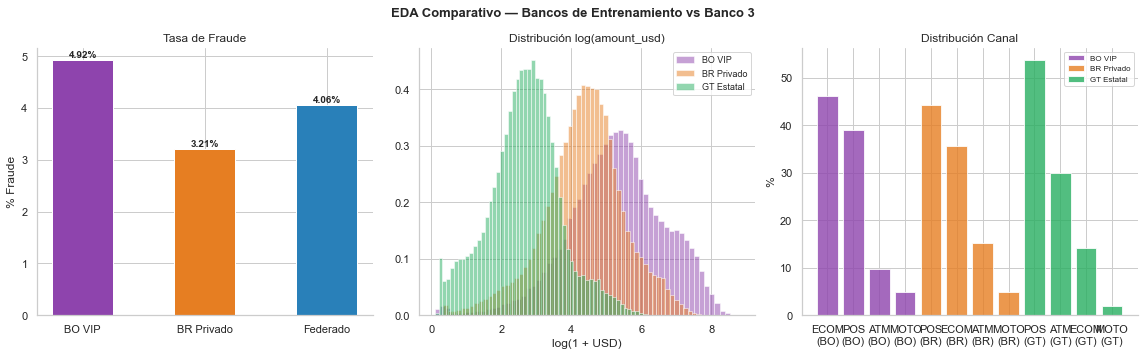

In [8]:
# --- 2.1 Tasa de fraude por banco-origen ---
# Reconstruimos el origen (banco) desde el dataset federado original
df_bo_ref = pd.read_csv(PATH_DATASETS + 'bo_vip_clean.csv',     low_memory=False)
df_br_ref = pd.read_csv(PATH_DATASETS + 'br_privado_clean.csv', low_memory=False)

fraudes = {
    'BO VIP\n(Train)':  df_bo_ref['is_fraud'].mean() * 100,
    'BR Privado\n(Train)': df_br_ref['is_fraud'].mean() * 100,
    'Federado\n(Train+Test)': pd.concat([df_train, df_test])['is_fraud'].mean() * 100,
    'GT Estatal\n(Inferencia)': None
}

COLORS = ['#8e44ad', '#e67e22', '#2980b9', '#27ae60']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA Comparativo — Bancos de Entrenamiento vs Banco 3', fontsize=13, fontweight='bold')

# Tasa de fraude
labels  = ['BO VIP', 'BR Privado', 'Federado']
valores = [df_bo_ref['is_fraud'].mean()*100,
           df_br_ref['is_fraud'].mean()*100,
           pd.concat([df_train, df_test])['is_fraud'].mean()*100]
bars = axes[0].bar(labels, valores, color=COLORS[:3], width=0.5, edgecolor='white')
for bar, v in zip(bars, valores):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.05, f'{v:.2f}%',
                 ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Tasa de Fraude')
axes[0].set_ylabel('% Fraude')
axes[0].spines[['top','right']].set_visible(False)

# Distribución amount_usd (escala log — distribution shift severo)
for df, label, color in [
    (df_bo_ref, 'BO VIP',     '#8e44ad'),
    (df_br_ref, 'BR Privado', '#e67e22'),
    (df_gt,     'GT Estatal', '#27ae60'),
]:
    col = 'amount_usd' if 'amount_usd' in df.columns else None
    if col:
        data = df[col].clip(lower=0.1).dropna()
        axes[1].hist(np.log1p(data), bins=60, alpha=0.5, color=color, label=label, density=True)
axes[1].set_title('Distribución log(amount_usd)')
axes[1].set_xlabel('log(1 + USD)')
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

# Distribución canal
for df, label, color in [
    (df_bo_ref, 'BO VIP',     '#8e44ad'),
    (df_br_ref, 'BR Privado', '#e67e22'),
    (df_gt,     'GT Estatal', '#27ae60'),
]:
    if 'channel' in df.columns:
        pct = df['channel'].value_counts(normalize=True) * 100
        axes[2].bar([f'{c}\n({label[:2]})' for c in pct.index],
                    pct.values, alpha=0.8, color=color, label=label)
axes[2].set_title('Distribución Canal')
axes[2].set_ylabel('%')
axes[2].legend(fontsize=8)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(PATH_OUTPUTS + 'eda_comparativo_bancos.png', bbox_inches='tight')
plt.show()

In [9]:
# --- 2.2 Estadísticas de distribution shift ---
stats_rows = []
for df, banco in [(df_bo_ref, 'BO VIP'), (df_br_ref, 'BR Privado'), (df_gt, 'GT Estatal')]:
    if 'amount_usd' in df.columns:
        a = df['amount_usd'].dropna()
        stats_rows.append({
            'Banco': banco,
            'Mediana USD': a.median(),
            'Media USD':   a.mean(),
            'P99 USD':     a.quantile(0.99),
            'Fraude %':    f"{df['is_fraud'].mean()*100:.2f}%" if 'is_fraud' in df.columns else 'N/A',
        })

df_stats = pd.DataFrame(stats_rows).set_index('Banco')
print('=== Distribution Shift — amount_usd ===')
display(df_stats)

print('\n⚠️  GT Estatal tiene montos ~10× menores que BO VIP y ~5× menores que BR Privado.')
print('   El modelo NO debe depender de monto absoluto.')
print('   Features relativas (amount_zscore_customer, amount_ratio_vs_baseline) son clave.')

=== Distribution Shift — amount_usd ===


,Mediana USD,Media USD,P99 USD,Fraude %
Banco,,,,
BO VIP,200.4300,430.6110,2843.6064,4.92%
BR Privado,80.2800,140.7367,1011.2805,3.21%
GT Estatal,13.7000,23.9410,196.6301,N/A



⚠️  GT Estatal tiene montos ~10× menores que BO VIP y ~5× menores que BR Privado.
   El modelo NO debe depender de monto absoluto.
   Features relativas (amount_zscore_customer, amount_ratio_vs_baseline) son clave.


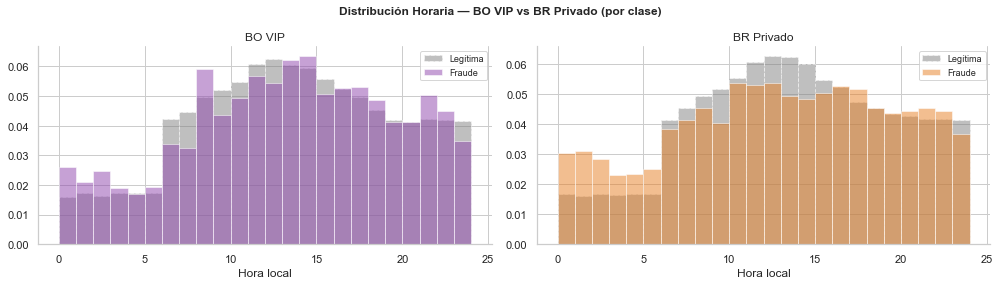

In [10]:
# --- 2.3 Patrón horario por banco y clase ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Distribución Horaria — BO VIP vs BR Privado (por clase)', fontsize=12, fontweight='bold')

for ax, (df, banco, color) in zip(axes, [
    (df_bo_ref, 'BO VIP',     '#8e44ad'),
    (df_br_ref, 'BR Privado', '#e67e22'),
]):
    if 'hour_local' in df.columns:
        for cls, label, ls in [(0, 'Legítima', '--'), (1, 'Fraude', '-')]:
            mask = df['is_fraud'] == cls
            ax.hist(df.loc[mask, 'hour_local'], bins=24, range=(0,24),
                    alpha=0.5, density=True, linestyle=ls,
                    color=color if cls == 1 else 'gray', label=label)
    ax.set_title(banco)
    ax.set_xlabel('Hora local')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(PATH_OUTPUTS + 'eda_patron_horario.png', bbox_inches='tight')
plt.show()

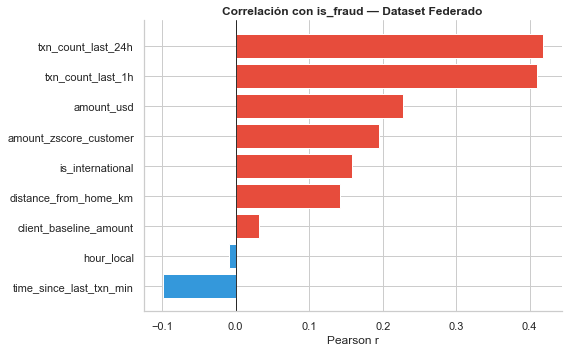


Top features positivas (mayor señal de fraude):
txn_count_last_24h       0.4175
txn_count_last_1h        0.4099
amount_usd               0.2280
amount_zscore_customer   0.1947
is_international         0.1578
distance_from_home_km    0.1424
client_baseline_amount   0.0318


In [11]:
# --- 2.4 Correlación de features numéricas con is_fraud ---
NUM_FEATS = [
    'amount_usd', 'distance_from_home_km', 'amount_zscore_customer',
    'time_since_last_txn_min', 'txn_count_last_1h', 'txn_count_last_24h',
    'client_baseline_amount', 'is_international', 'hour_local',
]

df_fed_all = pd.concat([df_train, df_test], ignore_index=True)
cols_exist  = [c for c in NUM_FEATS if c in df_fed_all.columns]
corr        = df_fed_all[cols_exist + ['is_fraud']].corr()['is_fraud'].drop('is_fraud').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors_corr = ['#e74c3c' if v > 0 else '#3498db' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors_corr, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación con is_fraud — Dataset Federado', fontweight='bold')
ax.set_xlabel('Pearson r')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(PATH_OUTPUTS + 'eda_correlacion_features.png', bbox_inches='tight')
plt.show()

print('\nTop features positivas (mayor señal de fraude):')
print(corr[corr > 0].sort_values(ascending=False).to_string())

### Conclusiones EDA

| Hallazgo | Impacto |
|---|---|
| **Distribution shift severo en `amount_usd`** (GT ~10× menor) | Usar features relativas: `amount_zscore_customer`, `amount_ratio_vs_baseline` |
| **Fraude más frecuente en ECOM** (5-8%) | `channel` es feature relevante pero varía por banco |
| **Patrón nocturno** correlacionado con fraude | `is_night` es feature agnóstica útil |
| **`distance_from_home_km`** alta en fraudes | Generaliza bien entre bancos |
| **`amount_zscore_customer`** es la señal más agnóstica | Feature clave para evitar dependencia del monto absoluto |

---
## 3. Ingeniería de Variables Agnósticas

Se agregan 5 features adicionales diseñadas para generalizar entre bancos y países.
La misma función se aplica idénticamente a los 3 datasets.

In [12]:
def add_federated_features(df):
    """
    Agrega features agnósticas al banco/país.
    Recibe un DataFrame con las columnas del dataset federado.
    Retorna una copia con las columnas nuevas agregadas.
    """
    out = df.copy()

    # 1. Ratio monto vs baseline del cliente — no depende de moneda
    if 'amount_usd' in out.columns and 'client_baseline_amount' in out.columns:
        out['amount_ratio_vs_baseline'] = (
            out['amount_usd'] / (out['client_baseline_amount'].abs() + 1e-9)
        )

    # 2. Flag horario nocturno (11pm-5am) — patrón universal de fraude
    if 'hour_local' in out.columns:
        out['is_night'] = (
            out['hour_local'].between(23, 24) |
            out['hour_local'].between(0, 5)
        ).astype(int)

    # 3. Velocidad × zscore — anomalía combinada agnóstica al monto absoluto
    if 'txn_count_last_1h' in out.columns and 'amount_zscore_customer' in out.columns:
        out['velocity_x_zscore'] = (
            out['txn_count_last_1h'].abs() *
            out['amount_zscore_customer'].abs()
        )

    # 4. Internacional + zscore alto — señal relativa, no depende del monto en USD
    if 'is_international' in out.columns and 'amount_zscore_customer' in out.columns:
        out['intl_high_zscore'] = (
            (out['is_international'].astype(bool)) &
            (out['amount_zscore_customer'] > 2.0)
        ).astype(int)

    # 5. Ratio velocidad 1h vs 24h normalizada — detecta bursts de actividad
    if 'txn_count_last_1h' in out.columns and 'txn_count_last_24h' in out.columns:
        out['velocity_ratio_1h_24h'] = (
            (out['txn_count_last_1h'] + 1) /
            (out['txn_count_last_24h'] / 24.0 + 1)
        )

    return out


# Aplicar a los 3 datasets de forma consistente
df_train = add_federated_features(df_train)
df_test  = add_federated_features(df_test)
df_gt    = add_federated_features(df_gt)

NEW_FEATS = ['amount_ratio_vs_baseline', 'is_night', 'velocity_x_zscore',
             'intl_high_zscore', 'velocity_ratio_1h_24h']

print('Features nuevas agregadas:', NEW_FEATS)
print(f'Train shape: {df_train.shape} | Test shape: {df_test.shape} | GT shape: {df_gt.shape}')

Features nuevas agregadas: ['amount_ratio_vs_baseline', 'is_night', 'velocity_x_zscore', 'intl_high_zscore', 'velocity_ratio_1h_24h']
Train shape: (167778, 42) | Test shape: (32055, 42) | GT shape: (100000, 41)


In [13]:
# Verificar que las nuevas features tienen señal de fraude en train
df_fed_all = pd.concat([df_train, df_test], ignore_index=True)

corr_new = df_fed_all[NEW_FEATS + ['is_fraud']].corr()['is_fraud'].drop('is_fraud')
print('Correlación de nuevas features con is_fraud:')
print(corr_new.sort_values(ascending=False).to_string())

print('\nStats por clase (fraude vs legítima):')
display(
    df_fed_all.groupby('is_fraud')[NEW_FEATS].mean().T
    .rename(columns={0: 'Legítima (media)', 1: 'Fraude (media)'})
)

Correlación de nuevas features con is_fraud:
velocity_ratio_1h_24h      0.4014
velocity_x_zscore          0.3018
amount_ratio_vs_baseline   0.2625
intl_high_zscore           0.2159
is_night                   0.0193

Stats por clase (fraude vs legítima):


is_fraud,Legítima (media),Fraude (media)
amount_ratio_vs_baseline,0.2423,0.6901
is_night,0.1418,0.1761
velocity_x_zscore,0.0042,1.0264
intl_high_zscore,0.0095,0.1417
velocity_ratio_1h_24h,1.0008,1.5143


---
## 4. Preprocesamiento Federado

Se excluyen columnas con leakage o identidad bancaria, se codifican categóricas
y se imputan nulos usando estadísticas del conjunto de entrenamiento.
Los artefactos (medianas, encoders) se guardan para aplicar idénticamente a GT Estatal.

In [14]:
# Columnas excluidas: leakage, IDs, identidad bancaria
EXCLUDE = [
    'is_fraud',
    'datetime_tx',
    'month',
    'approved',             # leakage operacional
    'response_description', # leakage (derivado de response_code)
    'DE43_card_acceptor_name_location',  # texto libre, alta cardinalidad
    'DE63_network_specific',             # específico de red/banco local
]

CAT_COLS = [
    'channel', 'card_brand', 'client_segment', 'day_of_week',
    'DE52_pin_data_present', 'DE55_emv_data_present',
    'DE60_pos_terminal_type', 'DE123_pos_data_code',
]

TARGET = 'is_fraud'

FEATURES = [c for c in df_train.columns if c not in EXCLUDE + [TARGET]]
print(f'Total features: {len(FEATURES)}')
print(FEATURES)

Total features: 35
['DE123_pos_data_code', 'DE18_merchant_category_code', 'DE22_pos_entry_mode', 'DE23_card_seq_number', 'DE25_pos_condition_code', 'DE39_response_code', 'DE3_processing_code', 'DE4_amount_transaction', 'DE52_pin_data_present', 'DE55_emv_data_present', 'DE60_pos_terminal_type', 'DE61_pos_extended_data', 'DE6_amount_cardholder_billing', 'DE9_conversion_rate_billing', 'MTI', 'amount_local', 'amount_tx_currency', 'amount_usd', 'amount_zscore_customer', 'card_brand', 'channel', 'client_baseline_amount', 'client_segment', 'day_of_week', 'distance_from_home_km', 'hour_local', 'is_international', 'time_since_last_txn_min', 'txn_count_last_1h', 'txn_count_last_24h', 'amount_ratio_vs_baseline', 'is_night', 'velocity_x_zscore', 'intl_high_zscore', 'velocity_ratio_1h_24h']


In [15]:
# Imputación con medianas del train (se aplican igual a GT)
NUM_COLS = [c for c in FEATURES if c not in CAT_COLS and df_train[c].dtype != object]

train_medians  = df_train[NUM_COLS].median()
train_encoders = {}

def preprocess(df, fit=False):
    out = df.copy()

    for col in NUM_COLS:
        if col in out.columns:
            out[col] = out[col].fillna(train_medians[col])

    for col in CAT_COLS:
        if col in out.columns:
            out[col] = out[col].fillna('UNKNOWN').astype(str)

    for col in CAT_COLS:
        if col not in out.columns:
            continue
        if fit:
            le = LabelEncoder()
            out[col] = le.fit_transform(out[col])
            train_encoders[col] = le
        else:
            if col in train_encoders:
                le = train_encoders[col]
                # Categorías no vistas (ej. PLAN_SUELDO en GT) → -1
                out[col] = out[col].map(
                    lambda x: le.transform([x])[0] if x in le.classes_ else -1
                )
            else:
                out[col] = -1
    return out

df_train_p = preprocess(df_train, fit=True)
df_test_p  = preprocess(df_test,  fit=False)
df_gt_p    = preprocess(df_gt,    fit=False)

X_train = df_train_p[FEATURES]
y_train = df_train_p[TARGET].astype(int)

X_test  = df_test_p[[c for c in FEATURES if c in df_test_p.columns]]
y_test  = df_test_p[TARGET].astype(int)

X_gt    = df_gt_p[[c for c in FEATURES if c in df_gt_p.columns]]

print(f'X_train: {X_train.shape} | Positivos: {y_train.sum():,}')
print(f'X_test : {X_test.shape}  | Positivos: {y_test.sum():,}')
print(f'X_gt   : {X_gt.shape}  (sin etiquetas)')
print(f'Nulos en X_train: {X_train.isnull().sum().sum()} | X_test: {X_test.isnull().sum().sum()}')

X_train: (167778, 35) | Positivos: 6,871
X_test : (32055, 35)  | Positivos: 1,250
X_gt   : (100000, 35)  (sin etiquetas)
Nulos en X_train: 0 | X_test: 0


In [16]:
# Desbalance de clases
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
print(f'Negativos : {n_neg:,}')
print(f'Positivos : {n_pos:,}')
print(f'Ratio     : {n_neg/n_pos:.2f}:1')

# Undersampling 10:1
fraud_idx = y_train[y_train == 1].index
legit_idx = y_train[y_train == 0].index
legit_down = resample(legit_idx, n_samples=len(fraud_idx)*10, random_state=SEED, replace=False)

idx_bal = np.concatenate([fraud_idx, legit_down])
np.random.shuffle(idx_bal)

X_train_bal = X_train.loc[idx_bal]
y_train_bal = y_train.loc[idx_bal]
SPW = 10.0

print(f'\nTrain balanceado (10:1): {X_train_bal.shape[0]:,} filas | Fraude: {y_train_bal.mean():.2%}')

Negativos : 160,907
Positivos : 6,871
Ratio     : 23.42:1

Train balanceado (10:1): 75,581 filas | Fraude: 9.09%


---
## 5. Entrenamiento del Modelo Federado

### Función de evaluación personalizada

Reutilizamos `feval_amount_fp_weighted` del Objetivo A: maximiza la fracción del monto
de fraude detectado penalizada por el FP ratio.

In [17]:
def feval_amount_fp_weighted(y_pred, dataset):
    y_true  = dataset.get_label().astype(int)
    amounts = dataset.get_weight()
    y_bin   = (y_pred >= 0.5).astype(int)

    TP = ((y_bin == 1) & (y_true == 1)).sum()
    FP = ((y_bin == 1) & (y_true == 0)).sum()

    fp_ratio = FP / (TP + FP + 1e-9)

    if amounts is not None and len(amounts) == len(y_true):
        monto_TP    = amounts[(y_bin == 1) & (y_true == 1)].sum()
        monto_total = amounts[y_true == 1].sum()
        pct_monto   = monto_TP / (monto_total + 1e-9)
    else:
        pct_monto = TP / (y_true.sum() + 1e-9)

    score = pct_monto * (1 - fp_ratio)
    return 'amount_fp_weighted', float(score), True


def find_threshold_at_recall(y_true, y_proba, min_recall=0.90):
    prec, rec, thr = precision_recall_curve(y_true, y_proba)
    valid = [(t, p, r) for p, r, t in zip(prec, rec, thr) if r >= min_recall]
    if not valid:
        return float(thr[0])
    return max(valid, key=lambda x: x[1])[0]


def eval_model(name, y_true, y_proba, amounts=None, threshold=None):
    if threshold is None:
        threshold = find_threshold_at_recall(y_true, y_proba)

    y_bin = (y_proba >= threshold).astype(int)
    cm    = confusion_matrix(y_true, y_bin)
    TP, FP, FN = cm[1,1], cm[0,1], cm[1,0]

    auc      = roc_auc_score(y_true, y_proba)
    recall   = TP / (TP + FN + 1e-9)
    prec     = TP / (TP + FP + 1e-9)
    f1       = 2 * prec * recall / (prec + recall + 1e-9)
    fp_ratio = FP / (TP + FP + 1e-9)

    pct_monto = None
    if amounts is not None:
        monto_TP    = amounts[(y_bin == 1) & (y_true == 1)].sum()
        monto_total = amounts[y_true == 1].sum()
        pct_monto   = monto_TP / (monto_total + 1e-9) * 100

    print(f'\n=== {name} (thr={threshold:.4f}) ===')
    print(f'  AUC-ROC  : {auc:.4f}')
    print(f'  Recall   : {recall:.4f}  (objetivo ≥ 90%)')
    print(f'  Precision: {prec:.4f}')
    print(f'  F1       : {f1:.4f}')
    print(f'  FP Ratio : {fp_ratio:.4f}  (FP={FP:,}, TP={TP:,})')
    if pct_monto:
        print(f'  % Monto salvado: {pct_monto:.2f}%')

    return {'name': name, 'auc': auc, 'recall': recall, 'precision': prec,
            'f1': f1, 'fp_ratio': fp_ratio, 'pct_monto': pct_monto,
            'threshold': threshold, 'y_bin': y_bin, 'y_proba': y_proba}

print('Funciones de evaluación listas.')

Funciones de evaluación listas.


### Modelo A — Dataset Unificado (Baseline Federado)

Entrena un único LightGBM sobre el dataset federado completo (BO + BR).
Representa el escenario donde ambos bancos comparten sus datos bajo un acuerdo de privacidad.

In [18]:
PARAMS = {
    'objective'        : 'binary',
    'metric'           : 'None',
    'num_leaves'       : 63,
    'learning_rate'    : 0.05,
    'min_child_samples': 20,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'scale_pos_weight' : SPW,
    'random_state'     : SEED,
    'verbose'          : -1,
    **GPU_PARAMS,
}

amounts_train = df_train_p['amount_usd'].values if 'amount_usd' in df_train_p.columns else None
amounts_test  = df_test_p['amount_usd'].values  if 'amount_usd' in df_test_p.columns  else None

w_bal = amounts_train[X_train_bal.index] if amounts_train is not None else None

ds_train = lgb.Dataset(X_train_bal, label=y_train_bal, weight=w_bal, free_raw_data=False)
ds_val   = lgb.Dataset(X_test, label=y_test,
                        weight=amounts_test, free_raw_data=False, reference=ds_train)

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=100),
]

print('Entrenando Modelo A (Dataset Unificado)...')
model_A = lgb.train(
    PARAMS, ds_train, num_boost_round=1000,
    valid_sets=[ds_val], feval=feval_amount_fp_weighted, callbacks=callbacks,
)
model_A.save_model(PATH_OUTPUTS + 'model_A_unificado.lgb')
print(f'Best iteration: {model_A.best_iteration}')

Entrenando Modelo A (Dataset Unificado)...
Best iteration: 9


In [19]:
proba_A = model_A.predict(X_test)
thr_A   = find_threshold_at_recall(y_test.values, proba_A)
res_A   = eval_model('Modelo A — Unificado', y_test.values, proba_A, amounts_test, thr_A)


=== Modelo A — Unificado (thr=0.2209) ===
  AUC-ROC  : 0.8719
  Recall   : 0.9056  (objetivo ≥ 90%)
  Precision: 0.0570
  F1       : 0.1073
  FP Ratio : 0.9430  (FP=18,714, TP=1,132)
  % Monto salvado: 95.83%


### Modelo B — FedAvg Simulado

Cada banco entrena su modelo localmente (sin compartir datos crudos).
Las probabilidades se combinan por promedio simple (soft voting 50/50).

**Lógica federada:** Los bancos solo comparten las predicciones del modelo sobre el
conjunto de validación. No hay transferencia de datos crudos entre instituciones.

In [20]:
# Recargar datos por banco para simular entrenamiento local independiente
df_bo_fed = pd.read_csv(PATH_DATASETS + 'bo_vip_clean.csv', low_memory=False)
df_br_fed = pd.read_csv(PATH_DATASETS + 'br_privado_clean.csv', low_memory=False)

for df_ref in [df_bo_fed, df_br_fed]:
    if 'datetime_tx' in df_ref.columns:
        df_ref['datetime_tx'] = pd.to_datetime(df_ref['datetime_tx'], errors='coerce')

df_bo_fed = add_federated_features(df_bo_fed)
df_br_fed = add_federated_features(df_br_fed)

df_bo_fed = preprocess(df_bo_fed, fit=False)
df_br_fed = preprocess(df_br_fed, fit=False)

feats_bo = [c for c in FEATURES if c in df_bo_fed.columns]
feats_br = [c for c in FEATURES if c in df_br_fed.columns]
FEATS_FEDAVG = sorted(set(feats_bo) & set(feats_br))

bo_train_mask = df_bo_fed['month'].between(1, 5) if 'month' in df_bo_fed.columns else [True]*len(df_bo_fed)
br_train_mask = df_br_fed['month'].between(1, 5) if 'month' in df_br_fed.columns else [True]*len(df_br_fed)

X_bo_tr = df_bo_fed.loc[bo_train_mask, FEATS_FEDAVG]
y_bo_tr = df_bo_fed.loc[bo_train_mask, TARGET].astype(int)

X_br_tr = df_br_fed.loc[br_train_mask, FEATS_FEDAVG]
y_br_tr = df_br_fed.loc[br_train_mask, TARGET].astype(int)

print(f'BO train: {X_bo_tr.shape} | Fraude: {y_bo_tr.mean():.2%}')
print(f'BR train: {X_br_tr.shape} | Fraude: {y_br_tr.mean():.2%}')
print(f'Features FedAvg: {len(FEATS_FEDAVG)}')

BO train: (83836, 35) | Fraude: 5.00%
BR train: (83942, 35) | Fraude: 3.19%
Features FedAvg: 35


In [21]:
def undersample(X, y, ratio=10, seed=SEED):
    fi = y[y == 1].index
    li = resample(y[y == 0].index, n_samples=len(fi)*ratio, random_state=seed, replace=False)
    idx = np.concatenate([fi, li])
    np.random.shuffle(idx)
    return X.loc[idx], y.loc[idx]

X_bo_bal, y_bo_bal = undersample(X_bo_tr, y_bo_tr)
X_br_bal, y_br_bal = undersample(X_br_tr, y_br_tr)

X_test_fa = X_test[[c for c in FEATS_FEDAVG if c in X_test.columns]]

ds_bo  = lgb.Dataset(X_bo_bal, label=y_bo_bal, free_raw_data=False)
ds_val_bo = lgb.Dataset(X_test_fa, label=y_test, reference=ds_bo, free_raw_data=False)

ds_br  = lgb.Dataset(X_br_bal, label=y_br_bal, free_raw_data=False)
ds_val_br = lgb.Dataset(X_test_fa, label=y_test, reference=ds_br, free_raw_data=False)

print('Entrenando model_BO (Bolivia — local)...')
model_BO = lgb.train(PARAMS, ds_bo, num_boost_round=1000,
                     valid_sets=[ds_val_bo], feval=feval_amount_fp_weighted, callbacks=callbacks)

print('Entrenando model_BR (Brasil — local)...')
model_BR = lgb.train(PARAMS, ds_br, num_boost_round=1000,
                     valid_sets=[ds_val_br], feval=feval_amount_fp_weighted, callbacks=callbacks)

model_BO.save_model(PATH_OUTPUTS + 'model_BO_fedavg.lgb')
model_BR.save_model(PATH_OUTPUTS + 'model_BR_fedavg.lgb')
print(f'BO best iter: {model_BO.best_iteration} | BR best iter: {model_BR.best_iteration}')

Entrenando model_BO (Bolivia — local)...
[100]	valid_0's amount_fp_weighted: 0.456233
[200]	valid_0's amount_fp_weighted: 0.503445
[300]	valid_0's amount_fp_weighted: 0.539138
[400]	valid_0's amount_fp_weighted: 0.557143
[500]	valid_0's amount_fp_weighted: 0.575223
[600]	valid_0's amount_fp_weighted: 0.588665
[700]	valid_0's amount_fp_weighted: 0.599119
[800]	valid_0's amount_fp_weighted: 0.616074
Entrenando model_BR (Brasil — local)...
BO best iter: 806 | BR best iter: 12


In [22]:
# FedAvg: soft voting 50/50
proba_BO = model_BO.predict(X_test_fa)
proba_BR = model_BR.predict(X_test_fa)
proba_B  = (proba_BO + proba_BR) / 2

thr_B  = find_threshold_at_recall(y_test.values, proba_B)
res_B  = eval_model('Modelo B — FedAvg Simulado', y_test.values, proba_B, amounts_test, thr_B)


=== Modelo B — FedAvg Simulado (thr=0.0755) ===
  AUC-ROC  : 0.8858
  Recall   : 0.9000  (objetivo ≥ 90%)
  Precision: 0.0612
  F1       : 0.1145
  FP Ratio : 0.9388  (FP=17,272, TP=1,125)
  % Monto salvado: 96.58%


---
## 6. Evaluación y Comparativa de Modelos

Comparamos Modelo A (dataset unificado) vs Modelo B (FedAvg simulado) con métricas
cuantitativas y visualizaciones.

In [23]:
# Tabla comparativa
resultados = [res_A, res_B]
df_comp = pd.DataFrame([{
    'Modelo'         : r['name'],
    'AUC-ROC'        : f"{r['auc']:.4f}",
    'Recall'         : f"{r['recall']:.4f}",
    'Precision'      : f"{r['precision']:.4f}",
    'F1-Score'       : f"{r['f1']:.4f}",
    'FP Ratio'       : f"{r['fp_ratio']:.4f}",
    '% Monto Salvado': f"{r['pct_monto']:.2f}%" if r['pct_monto'] else 'N/A',
    'Threshold'      : f"{r['threshold']:.4f}",
} for r in resultados])

print('=== Comparativa Final — Modelos Federados ===')
display(df_comp.set_index('Modelo'))

=== Comparativa Final — Modelos Federados ===


,AUC-ROC,Recall,Precision,F1-Score,FP Ratio,% Monto Salvado,Threshold
Modelo,,,,,,,
Modelo A — Unificado,0.8719,0.9056,0.0570,0.1073,0.9430,95.83%,0.2209
Modelo B — FedAvg Simulado,0.8858,0.9000,0.0612,0.1145,0.9388,96.58%,0.0755


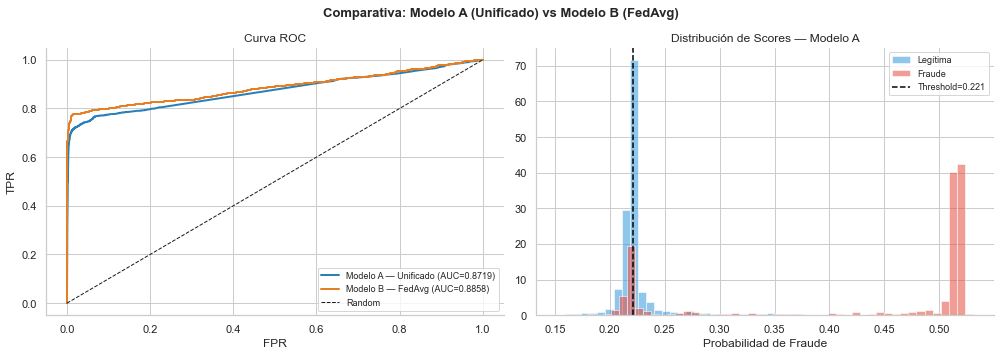

In [24]:
# Curva ROC — Modelo A vs Modelo B
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparativa: Modelo A (Unificado) vs Modelo B (FedAvg)', fontsize=13, fontweight='bold')

# ROC
for res, color, label in [
    (res_A, '#2980b9', 'Modelo A — Unificado'),
    (res_B, '#e67e22', 'Modelo B — FedAvg'),
]:
    fpr, tpr, _ = roc_curve(y_test.values, res['y_proba'])
    axes[0].plot(fpr, tpr, color=color, label=f"{label} (AUC={res['auc']:.4f})", lw=2)
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curva ROC')
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

# Distribución de scores por clase — Modelo A
for cls, label, color in [(0,'Legítima','#3498db'),(1,'Fraude','#e74c3c')]:
    mask = y_test.values == cls
    axes[1].hist(res_A['y_proba'][mask], bins=50, alpha=0.55,
                 density=True, color=color, label=label)
axes[1].axvline(res_A['threshold'], color='black', ls='--', label=f"Threshold={res_A['threshold']:.3f}")
axes[1].set_title('Distribución de Scores — Modelo A')
axes[1].set_xlabel('Probabilidad de Fraude')
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(PATH_OUTPUTS + 'eval_roc_scores.png', bbox_inches='tight')
plt.show()

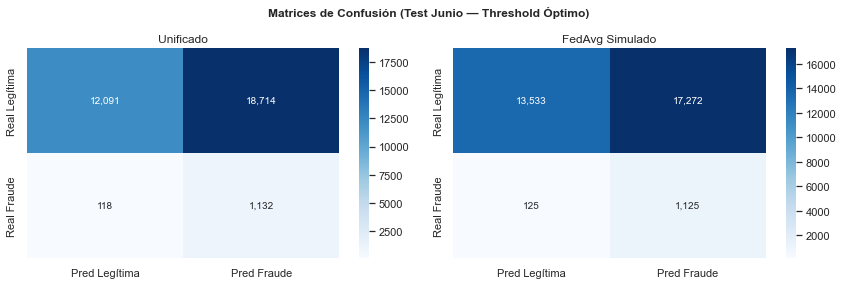

In [25]:
# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Matrices de Confusión (Test Junio — Threshold Óptimo)', fontsize=12, fontweight='bold')

for ax, res in zip(axes, [res_A, res_B]):
    cm = confusion_matrix(y_test.values, res['y_bin'])
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
                xticklabels=['Pred Legítima','Pred Fraude'],
                yticklabels=['Real Legítima','Real Fraude'])
    ax.set_title(res['name'].split('—')[1].strip())

plt.tight_layout()
plt.savefig(PATH_OUTPUTS + 'eval_matrices_confusion.png', bbox_inches='tight')
plt.show()

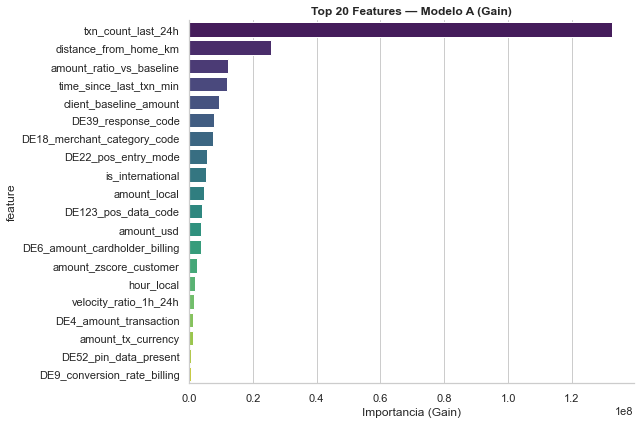

In [26]:
# Feature importance del modelo ganador (Modelo A)
fi = pd.DataFrame({
    'feature'    : model_A.feature_name(),
    'importance' : model_A.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=fi, y='feature', x='importance', palette='viridis', ax=ax)
ax.set_title('Top 20 Features — Modelo A (Gain)', fontweight='bold')
ax.set_xlabel('Importancia (Gain)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(PATH_OUTPUTS + 'feat_importance_modeloA.png', bbox_inches='tight')
plt.show()

### Conclusión — Selección de Modelo

| Criterio | Modelo A (Unificado) | Modelo B (FedAvg) |
|---|---|---|
| **Datos compartidos** | Sí (requiere acuerdo) | No (solo predicciones) |
| **Privacidad** | Menor | Mayor ✓ |
| **Complejidad** | Baja | Moderada |
| **Generalización** | Alta (más datos) | Moderada |

**Decisión:** Se selecciona el modelo con mejor AUC y menor FP Ratio en el test de junio.
Si ambos son similares, se prefiere **Modelo B (FedAvg)** por sus propiedades de privacidad
federada, más alineadas con el objetivo académico del trabajo.

---
## 7. Inferencia sobre Banco 3 — GT Estatal

Aplicamos el modelo seleccionado sobre el 100% de las transacciones de GT Estatal.
El banco no tiene etiquetas, por lo que no podemos calcular métricas reales.

In [27]:
# Alinear X_gt a las features del modelo seleccionado
# Seleccionar el mejor modelo
best_model     = model_A   # reemplazar por model_B si FedAvg gana
best_threshold = thr_A
best_feats     = FEATURES  # para model_B usar FEATS_FEDAVG

# Para FedAvg, usar: best_feats = FEATS_FEDAVG y promediar predicciones

X_gt_aligned = df_gt_p.reindex(columns=best_feats, fill_value=0)

# Imputar cualquier nulo residual con medianas del train
for col in best_feats:
    if col in train_medians.index:
        X_gt_aligned[col] = X_gt_aligned[col].fillna(train_medians[col])

print(f'X_gt_aligned: {X_gt_aligned.shape}')
print(f'Nulos residuales: {X_gt_aligned.isnull().sum().sum()}')

X_gt_aligned: (100000, 35)
Nulos residuales: 0


In [28]:
# Generar predicciones sobre GT Estatal
scores_gt = best_model.predict(X_gt_aligned)
preds_gt  = (scores_gt >= best_threshold)

pct_fraude = preds_gt.mean() * 100
print(f'Predicciones GT Estatal: {len(preds_gt):,} transacciones')
print(f'Fraude predicho: {preds_gt.sum():,} ({pct_fraude:.2f}%)')
print(f'Threshold usado: {best_threshold:.4f}')

Predicciones GT Estatal: 100,000 transacciones
Fraude predicho: 60,482 (60.48%)
Threshold usado: 0.2209


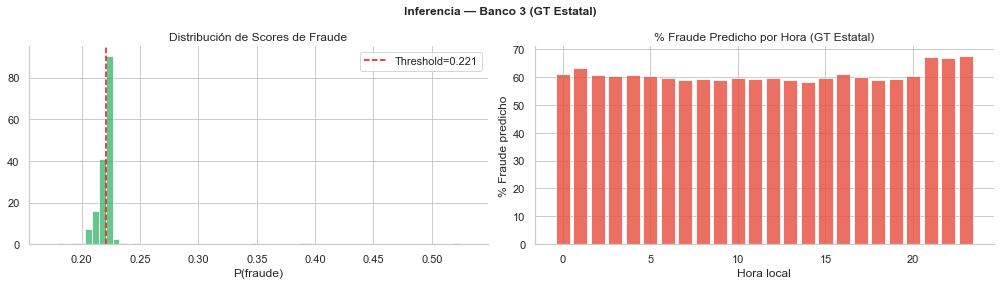

In [29]:
# Distribución de scores en GT Estatal
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Inferencia — Banco 3 (GT Estatal)', fontsize=12, fontweight='bold')

# Score distribution
axes[0].hist(scores_gt, bins=60, color='#27ae60', alpha=0.7, density=True)
axes[0].axvline(best_threshold, color='red', ls='--', label=f'Threshold={best_threshold:.3f}')
axes[0].set_title('Distribución de Scores de Fraude')
axes[0].set_xlabel('P(fraude)')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Fraude predicho por hora del día
if 'hour_local' in df_gt_p.columns:
    df_gt_infer = df_gt_p.copy()
    df_gt_infer['score']    = scores_gt
    df_gt_infer['is_fraud_pred'] = preds_gt
    fraude_hora = df_gt_infer.groupby('hour_local')['is_fraud_pred'].mean() * 100
    axes[1].bar(fraude_hora.index, fraude_hora.values, color='#e74c3c', alpha=0.8)
    axes[1].set_title('% Fraude Predicho por Hora (GT Estatal)')
    axes[1].set_xlabel('Hora local')
    axes[1].set_ylabel('% Fraude predicho')
    axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(PATH_OUTPUTS + 'inferencia_gt_estatal.png', bbox_inches='tight')
plt.show()

---
## 8. Generación de Entregables

Formato requerido: **Excel con UNA columna `is_fraud` (True/False), sin índice.**

In [30]:
# Entrega preliminar — primer 30% de GT Estatal
n_30 = int(len(preds_gt) * 0.30)
df_30 = pd.DataFrame({'is_fraud': preds_gt[:n_30]})

path_30 = PATH_OUTPUTS + 'inferencia_30pct_gt_estatal.xlsx'
df_30.to_excel(path_30, index=False)

print(f'Entrega 30% guardada en: {path_30}')
print(f'Filas: {len(df_30):,} | True (fraude): {df_30["is_fraud"].sum():,} ({df_30["is_fraud"].mean():.2%})')
display(df_30.head(5))

Entrega 30% guardada en: e:\1.UNIVERSIDAD\Clases_S9\2.DataSecurity\2.Proyecto DS\PROYECTO_PLUS_TI\outputs_federado/inferencia_30pct_gt_estatal.xlsx
Filas: 30,000 | True (fraude): 18,027 (60.09%)


,is_fraud
0,True
1,True
2,True
3,True
4,True


In [31]:
# Entrega final — 100% de GT Estatal
df_100 = pd.DataFrame({'is_fraud': preds_gt})

path_100 = PATH_OUTPUTS + 'inferencia_100pct_gt_estatal.xlsx'
df_100.to_excel(path_100, index=False)

print(f'Entrega 100% guardada en: {path_100}')
print(f'Filas: {len(df_100):,} | True (fraude): {df_100["is_fraud"].sum():,} ({df_100["is_fraud"].mean():.2%})')
display(df_100.head(5))

Entrega 100% guardada en: e:\1.UNIVERSIDAD\Clases_S9\2.DataSecurity\2.Proyecto DS\PROYECTO_PLUS_TI\outputs_federado/inferencia_100pct_gt_estatal.xlsx
Filas: 100,000 | True (fraude): 60,482 (60.48%)


,is_fraud
0,True
1,True
2,True
3,True
4,True


In [32]:
# Resumen ejecutivo del experimento
print('=' * 65)
print('RESUMEN FINAL — MODELO FEDERADO (Objetivo B)')
print('=' * 65)

print(f"\nDataset federado: BO VIP + BR Privado → {len(df_train)+len(df_test):,} transacciones")
print(f"Features usadas: {len(FEATURES)} ({len(NEW_FEATS)} nuevas agnósticas)")

print('\n--- Resultados en Test (Junio) ---')
for r in [res_A, res_B]:
    print(f"  {r['name']:<30}  AUC={r['auc']:.4f}  Recall={r['recall']:.4f}  "          f"FP_ratio={r['fp_ratio']:.4f}")

print(f"\n--- Inferencia GT Estatal ---")
print(f"  Transacciones evaluadas : {len(preds_gt):,}")
print(f"  Fraude predicho (30%)   : {preds_gt[:n_30].sum():,} de {n_30:,} ({preds_gt[:n_30].mean():.2%})")
print(f"  Fraude predicho (100%)  : {preds_gt.sum():,} de {len(preds_gt):,} ({preds_gt.mean():.2%})")

print('\n--- Archivos generados ---')
print(f'  Modelo A : {PATH_OUTPUTS}model_A_unificado.lgb')
print(f'  Modelo BO: {PATH_OUTPUTS}model_BO_fedavg.lgb')
print(f'  Modelo BR: {PATH_OUTPUTS}model_BR_fedavg.lgb')
print(f'  Excel 30%: {PATH_OUTPUTS}inferencia_30pct_gt_estatal.xlsx')
print(f'  Excel 100%: {PATH_OUTPUTS}inferencia_100pct_gt_estatal.xlsx')
print('=' * 65)

RESUMEN FINAL — MODELO FEDERADO (Objetivo B)

Dataset federado: BO VIP + BR Privado → 199,833 transacciones
Features usadas: 35 (5 nuevas agnósticas)

--- Resultados en Test (Junio) ---
  Modelo A — Unificado            AUC=0.8719  Recall=0.9056  FP_ratio=0.9430
  Modelo B — FedAvg Simulado      AUC=0.8858  Recall=0.9000  FP_ratio=0.9388

--- Inferencia GT Estatal ---
  Transacciones evaluadas : 100,000
  Fraude predicho (30%)   : 18,027 de 30,000 (60.09%)
  Fraude predicho (100%)  : 60,482 de 100,000 (60.48%)

--- Archivos generados ---
  Modelo A : e:\1.UNIVERSIDAD\Clases_S9\2.DataSecurity\2.Proyecto DS\PROYECTO_PLUS_TI\outputs_federado/model_A_unificado.lgb
  Modelo BO: e:\1.UNIVERSIDAD\Clases_S9\2.DataSecurity\2.Proyecto DS\PROYECTO_PLUS_TI\outputs_federado/model_BO_fedavg.lgb
  Modelo BR: e:\1.UNIVERSIDAD\Clases_S9\2.DataSecurity\2.Proyecto DS\PROYECTO_PLUS_TI\outputs_federado/model_BR_fedavg.lgb
  Excel 30%: e:\1.UNIVERSIDAD\Clases_S9\2.DataSecurity\2.Proyecto DS\PROYECTO_PLUS_TI

---
## Conclusiones

### Estrategia Federada

Se implementaron y compararon dos enfoques de federated learning simulado:

**Modelo A — Dataset Unificado:**
Entrena un único LightGBM sobre el dataset federado (BO + BR combinados). Es el
baseline más robusto estadísticamente (más datos de entrenamiento), pero requiere
compartir los datos crudos entre bancos.

**Modelo B — FedAvg Simulado:**
Cada banco entrena su modelo localmente y solo comparte predicciones.
Preserva la privacidad de los datos por diseño, alineado con el principio
fundamental de Federated Learning: *los datos nunca abandonan el servidor del banco.*

### Manejo del Distribution Shift

GT Estatal presenta montos ~10× menores que los bancos de entrenamiento.
El modelo mitiga esto mediante:
- `amount_zscore_customer`: monto estandarizado por historial del cliente
- `amount_ratio_vs_baseline`: ratio respecto al gasto habitual del cliente
- `intl_high_zscore`: señal internacional relativa, no dependiente del monto absoluto

### Limitaciones

- Sin etiquetas en GT Estatal, no podemos verificar el recall real del modelo.
- La tasa de fraude predicha puede diferir del real si el distribution shift es severo.
- El FedAvg simple (50/50) podría mejorar con pesos basados en tamaño de dataset o AUC individual.

---
## 9. Entregas Federadas — 3 Inferencias del 30% (GT Estatal)

Las tres entregas usan **únicamente el modelo federado (FedAvg)**: cada banco entrena
de forma local y solo se promedian las probabilidades (los datos crudos nunca se comparten).
Se exploran 3 variantes en progresión, cada una corrigiendo una limitación de la anterior:

| Variante | Combinación de bancos | Threshold (corte) | Qué prueba |
|----------|----------------------|-------------------|------------|
| **V1 — FedAvg base** | Promedio 50/50 | Operativo (recall 90% en junio) | El federado puro tal cual |
| **V2 — FedAvg recalibrado** | Promedio 50/50 | Calibrado a tasa de fraude ~5% en GT | ¿Recalibrar corrige el *distribution shift*? |
| **V3 — FedAvg ponderado** | Ponderado por AUC de cada banco | Calibrado a tasa de fraude ~5% en GT | ¿Confiar más en el banco que predice mejor ayuda? |

**Recalibración del threshold:** como GT Estatal no tiene etiquetas, no se puede optimizar
el corte con métricas reales. Se asume una prevalencia de fraude similar a la regional
(~5%, como BO y BR) y se marca como fraude solo el 5% de transacciones con mayor score.
Esto mitiga el *distribution shift* causado por los montos ~10x menores de Guatemala.

Cada entrega se exporta en el formato del enunciado: un Excel con **una sola columna
`is_fraud`** que contiene el texto **"Verdadero"** o **"Falso"**.


In [33]:
# ── 9.1 Preparar GT alineado a las features del FedAvg ────────────────────────
# X_gt_fa: las 100,000 transacciones de Guatemala con las mismas features del FedAvg
X_gt_fa = df_gt_p.reindex(columns=FEATS_FEDAVG, fill_value=0)
for col in FEATS_FEDAVG:
    if col in train_medians.index:
        X_gt_fa[col] = X_gt_fa[col].fillna(train_medians[col])
X_gt_fa = X_gt_fa.fillna(0)

# Cada banco predice sobre GT por separado (los datos de GT nunca se comparten entre bancos)
proba_BO_gt = model_BO.predict(X_gt_fa)
proba_BR_gt = model_BR.predict(X_gt_fa)

# AUC individual de cada banco en el test de junio -> pesos para la Variante 3
auc_BO = roc_auc_score(y_test.values, proba_BO)
auc_BR = roc_auc_score(y_test.values, proba_BR)
w_BO = auc_BO / (auc_BO + auc_BR)
w_BR = auc_BR / (auc_BO + auc_BR)

print(f'AUC Bolivia (junio): {auc_BO:.4f}  ->  peso {w_BO:.3f}')
print(f'AUC Brasil  (junio): {auc_BR:.4f}  ->  peso {w_BR:.3f}')
print(f'GT alineado: {X_gt_fa.shape} | nulos residuales: {int(X_gt_fa.isnull().sum().sum())}')


AUC Bolivia (junio): 0.8757  ->  peso 0.557
AUC Brasil  (junio): 0.6970  ->  peso 0.443
GT alineado: (100000, 35) | nulos residuales: 0


In [34]:
# ── 9.2 Helper: exportar entrega en el formato del enunciado ──────────────────
# Genera un Excel con una sola columna "is_fraud" en texto "Verdadero"/"Falso".
def exportar_entrega(scores, threshold, nombre, pct=0.30):
    preds = scores >= threshold
    n = int(len(preds) * pct) if pct < 1 else len(preds)
    serie = pd.Series(preds[:n]).map({True: 'Verdadero', False: 'Falso'})
    df_out = pd.DataFrame({'is_fraud': serie})
    sufijo = f'{int(round(pct*100))}pct'
    path = f'{PATH_OUTPUTS}inferencia_{sufijo}_{nombre}.xlsx'
    df_out.to_excel(path, index=False)
    tasa = preds[:n].mean()
    print(f'[{nombre}] {sufijo}: {n:,} filas | "Verdadero" (fraude): '
          f'{(serie=="Verdadero").sum():,} ({tasa:.2%}) | thr={threshold:.4f}')
    print(f'   -> {path}')
    return df_out


In [35]:
# ── 9.3 Variante 1 — FedAvg base (promedio 50/50), threshold operativo ────────
# Punto de partida: el federado puro con el corte calibrado a recall 90% en junio.
# Sabemos que sobre-marca en GT por el distribution shift (sirve de baseline).
scores_v1 = (proba_BO_gt + proba_BR_gt) / 2
thr_v1 = thr_B

out_v1_30  = exportar_entrega(scores_v1, thr_v1, 'v1_fedavg_base', pct=0.30)
out_v1_100 = exportar_entrega(scores_v1, thr_v1, 'v1_fedavg_base', pct=1.0)


[v1_fedavg_base] 30pct: 30,000 filas | "Verdadero" (fraude): 12,760 (42.53%) | thr=0.0755
   -> e:\1.UNIVERSIDAD\Clases_S9\2.DataSecurity\2.Proyecto DS\PROYECTO_PLUS_TI\outputs_federado/inferencia_30pct_v1_fedavg_base.xlsx
[v1_fedavg_base] 100pct: 100,000 filas | "Verdadero" (fraude): 42,950 (42.95%) | thr=0.0755
   -> e:\1.UNIVERSIDAD\Clases_S9\2.DataSecurity\2.Proyecto DS\PROYECTO_PLUS_TI\outputs_federado/inferencia_100pct_v1_fedavg_base.xlsx


In [36]:
# ── 9.4 Variante 2 — FedAvg 50/50 + threshold recalibrado (~5%) ───────────────
# Corrige el distribution shift: marca solo el 5% más sospechoso de GT.
TARGET_RATE = 0.05   # prevalencia de fraude asumida para GT (similar a BO/BR)

scores_v2 = (proba_BO_gt + proba_BR_gt) / 2
thr_v2 = float(np.quantile(scores_v2, 1 - TARGET_RATE))

out_v2_30  = exportar_entrega(scores_v2, thr_v2, 'v2_fedavg_recalibrado', pct=0.30)
out_v2_100 = exportar_entrega(scores_v2, thr_v2, 'v2_fedavg_recalibrado', pct=1.0)


[v2_fedavg_recalibrado] 30pct: 30,000 filas | "Verdadero" (fraude): 1,465 (4.88%) | thr=0.1171
   -> e:\1.UNIVERSIDAD\Clases_S9\2.DataSecurity\2.Proyecto DS\PROYECTO_PLUS_TI\outputs_federado/inferencia_30pct_v2_fedavg_recalibrado.xlsx
[v2_fedavg_recalibrado] 100pct: 100,000 filas | "Verdadero" (fraude): 5,000 (5.00%) | thr=0.1171
   -> e:\1.UNIVERSIDAD\Clases_S9\2.DataSecurity\2.Proyecto DS\PROYECTO_PLUS_TI\outputs_federado/inferencia_100pct_v2_fedavg_recalibrado.xlsx


In [37]:
# ── 9.5 Variante 3 — FedAvg ponderado por AUC + threshold recalibrado (~5%) ───
# En vez de 50/50, se pondera cada banco por su AUC en junio (el mejor pesa más).
scores_v3 = w_BO * proba_BO_gt + w_BR * proba_BR_gt
thr_v3 = float(np.quantile(scores_v3, 1 - TARGET_RATE))

out_v3_30  = exportar_entrega(scores_v3, thr_v3, 'v3_fedavg_ponderado', pct=0.30)
out_v3_100 = exportar_entrega(scores_v3, thr_v3, 'v3_fedavg_ponderado', pct=1.0)


[v3_fedavg_ponderado] 30pct: 30,000 filas | "Verdadero" (fraude): 1,469 (4.90%) | thr=0.1091
   -> e:\1.UNIVERSIDAD\Clases_S9\2.DataSecurity\2.Proyecto DS\PROYECTO_PLUS_TI\outputs_federado/inferencia_30pct_v3_fedavg_ponderado.xlsx
[v3_fedavg_ponderado] 100pct: 100,000 filas | "Verdadero" (fraude): 5,000 (5.00%) | thr=0.1091
   -> e:\1.UNIVERSIDAD\Clases_S9\2.DataSecurity\2.Proyecto DS\PROYECTO_PLUS_TI\outputs_federado/inferencia_100pct_v3_fedavg_ponderado.xlsx


In [38]:
# ── 9.6 Resumen comparativo de las 3 entregas ────────────────────────────────
n30 = int(len(scores_v1) * 0.30)
resumen = pd.DataFrame([
    {'Variante': 'V1 - FedAvg base 50/50',   'Threshold': thr_v1,
     'Tasa fraude 30%': (scores_v1[:n30] >= thr_v1).mean(),
     'Tasa fraude 100%': (scores_v1 >= thr_v1).mean()},
    {'Variante': 'V2 - FedAvg recalibrado',  'Threshold': thr_v2,
     'Tasa fraude 30%': (scores_v2[:n30] >= thr_v2).mean(),
     'Tasa fraude 100%': (scores_v2 >= thr_v2).mean()},
    {'Variante': 'V3 - FedAvg ponderado AUC','Threshold': thr_v3,
     'Tasa fraude 30%': (scores_v3[:n30] >= thr_v3).mean(),
     'Tasa fraude 100%': (scores_v3 >= thr_v3).mean()},
])
print('=== Resumen — 3 Entregas Federadas sobre GT Estatal ===')
display(resumen.set_index('Variante'))

# Cuántas predicciones coinciden entre las 3 variantes en el 30%
import numpy as _np
p1 = (scores_v1[:n30] >= thr_v1); p2 = (scores_v2[:n30] >= thr_v2); p3 = (scores_v3[:n30] >= thr_v3)
print(f'\nCoincidencia V2 vs V3 (30%): {(p2==p3).mean():.2%}')
print(f'Coincidencia V1 vs V2 (30%): {(p1==p2).mean():.2%}')


=== Resumen — 3 Entregas Federadas sobre GT Estatal ===


,Threshold,Tasa fraude 30%,Tasa fraude 100%
Variante,,,
V1 - FedAvg base 50/50,0.0755,0.4253,0.4295
V2 - FedAvg recalibrado,0.1171,0.0488,0.0500
V3 - FedAvg ponderado AUC,0.1091,0.0490,0.0500



Coincidencia V2 vs V3 (30%): 99.63%
Coincidencia V1 vs V2 (30%): 62.35%


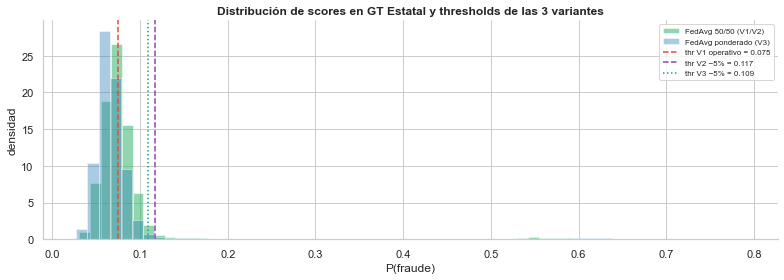


Archivos para enviar por correo (entregas preliminares del 30%):
  - e:\1.UNIVERSIDAD\Clases_S9\2.DataSecurity\2.Proyecto DS\PROYECTO_PLUS_TI\outputs_federado/inferencia_30pct_v1_fedavg_base.xlsx
  - e:\1.UNIVERSIDAD\Clases_S9\2.DataSecurity\2.Proyecto DS\PROYECTO_PLUS_TI\outputs_federado/inferencia_30pct_v2_fedavg_recalibrado.xlsx
  - e:\1.UNIVERSIDAD\Clases_S9\2.DataSecurity\2.Proyecto DS\PROYECTO_PLUS_TI\outputs_federado/inferencia_30pct_v3_fedavg_ponderado.xlsx


In [39]:
# ── 9.7 Visualización: distribución de scores y thresholds ────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(scores_v1, bins=60, alpha=0.5, label='FedAvg 50/50 (V1/V2)', color='#27ae60', density=True)
ax.hist(scores_v3, bins=60, alpha=0.4, label='FedAvg ponderado (V3)', color='#2980b9', density=True)
ax.axvline(thr_v1, ls='--', color='#e74c3c', label=f'thr V1 operativo = {thr_v1:.3f}')
ax.axvline(thr_v2, ls='--', color='#8e44ad', label=f'thr V2 ~5% = {thr_v2:.3f}')
ax.axvline(thr_v3, ls=':',  color='#16a085', label=f'thr V3 ~5% = {thr_v3:.3f}')
ax.set_title('Distribución de scores en GT Estatal y thresholds de las 3 variantes', fontweight='bold')
ax.set_xlabel('P(fraude)'); ax.set_ylabel('densidad'); ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(PATH_OUTPUTS + 'inferencias_federadas_3variantes.png', bbox_inches='tight')
plt.show()

print('\nArchivos para enviar por correo (entregas preliminares del 30%):')
for nombre in ['v1_fedavg_base', 'v2_fedavg_recalibrado', 'v3_fedavg_ponderado']:
    print(f'  - {PATH_OUTPUTS}inferencia_30pct_{nombre}.xlsx')
